# Do the metrics separate peptides whose serum fate is known?

## Scope

Every result so far is internal: a score correlates with a rate, a hazard orders
a set of candidate bonds. None of it says whether a peptide a biologist calls
**stable in serum** receives a different number from one called **labile**. This
notebook asks that question directly, on the two annotated sets the repository
holds, and reports the answer whether or not it is favourable.

## The two label sets, and why they test different things

| Set | Peptides | Label | What it tests |
| --- | --- | --- | --- |
| `controls_mic.csv` | 10 | `serum_fate` ∈ {stable, labile} | the panel-level hazard as a stability classifier |
| `clasp-controls.tsv` | 4 pairs | parent → engineered variant | whether the model moves in the published direction when one scaffold is modified |

The first is an unpaired comparison across unrelated scaffolds, so length,
composition and assay all vary together. The second is paired: each pair shares a
scaffold, and two of the pairs are length-matched to the residue, so a difference
cannot be a length artefact.

## What the model is allowed to predict

The hazard of the intact peptide is

$$\Lambda = \sum_\pi \sum_b w_\pi \exp\!\left(\alpha + \beta S^M_{\pi,b}\right),$$

and the expected time to the first cleavage is $1/\Lambda$. A labile peptide
should have the larger $\Lambda$, hence the shorter time. Because $\alpha$ is a
common offset it cancels in every comparison made here; only the ordering is
tested, never the absolute minutes.

## Power, stated before the result

With four stable and six labile peptides the most extreme possible one-sided
Mann-Whitney result is $p = 1/\binom{10}{4} = 0.0048$ at AUC $= 1$. With four
matched pairs a perfect sign test gives $p = 1/2^4 = 0.0625$. Neither set can
produce a small $p$ from a moderate effect, so the effect sizes are reported
alongside and carry most of the interpretation.

## Inputs and outputs

Inputs: `data/peptides_data/peptides_mic/controls_mic.csv`,
`configs/clasp-controls.tsv`, `results/2_07_model_panel.csv`,
`results/3_01_time_axis_calibration.csv`, `data/merops/`,
`data/reference/human_proteome/composition.json`.

Outputs: `results/3_03_control_discrimination.csv`,
`results/3_03_matched_pairs.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    ProteaseKinetics,
    first_cut_distribution,
    load_amino_acid_background,
    load_protease_panel,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
SCORE_SLOPE = 0.404 * np.log(10.0)
# Human neutrophil elastase, the one panel member for which the control table
# records a published stabilisation result on a named pair.
HNE_CODE = "S01.131"

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
calibration = pd.read_csv(common.RESULTS_ROOT / "3_01_time_axis_calibration.csv")
controls = pd.read_csv(common.CONTROLS_MIC_CSV)
clasp = pd.read_csv(common.ANALYSIS_ROOT / "configs" / "clasp-controls.tsv", sep="\t")

print(f"labelled serum controls: {len(controls)} ({controls['serum_fate'].value_counts().to_dict()})")
print(f"clasp control rows: {len(clasp)} over {clasp['peptide_id'].nunique()} peptides")

labelled serum controls: 10 ({'labile': 6, 'stable': 4})
clasp control rows: 28 over 13 peptides


## Assembling the three kinetics variants and the single-enzyme probe

The panel-level variants are the ones used in `4_01` and `4_02`. A fourth
variant carries HNE alone. It is not a serum model; it is the setting in which
the published pair result was measured, and it isolates whether the specificity
matrix of one enzyme sees the substitution that the experiment reports.

In [4]:
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(human_panel.codes)}
available = panel[panel["merops_code"].isin(index_of)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"]).copy()
alpha_of = dict(zip(calibration["weighting"], calibration["alpha"]))


def build(frame: pd.DataFrame, weights: np.ndarray, slope: float, intercept: float) -> ProteaseKinetics:
    """Assemble the panel for one weighting.

    :param frame: Panel rows to include.
    :param weights: Per-protease weight.
    :param slope: Score-to-log-intensity coefficient; zero switches the score off.
    :param intercept: Calibrated global offset.
    :return: The assembled kinetics.
    """

    return ProteaseKinetics(
        matrices=np.stack([matrices[index_of[code]] for code in frame["merops_code"]]),
        geometries=tuple(EventGeometry(value) for value in frame["event_geometry"]),
        weights=np.asarray(weights, dtype=float),
        codes=tuple(frame["merops_code"]),
        intercept=intercept,
        slope=slope,
    )


abundance_weights = (
    with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()
).to_numpy()
elastase = available[available["merops_code"] == HNE_CODE]
variants = {
    "uniform": build(available, np.ones(len(available)), SCORE_SLOPE, alpha_of["uniform"]),
    "concentration": build(with_abundance, abundance_weights, SCORE_SLOPE, alpha_of["concentration"]),
    "concentration_only": build(with_abundance, abundance_weights, 0.0, alpha_of["concentration"]),
    "elastase_only": build(elastase, np.ones(len(elastase)), SCORE_SLOPE, alpha_of["uniform"]),
}
print({name: len(kinetics.codes) for name, kinetics in variants.items()})

{'uniform': 57, 'concentration': 47, 'concentration_only': 47, 'elastase_only': 1}


## Test 1: the labelled serum controls

Each peptide receives the hazard of its intact form, and the same quantity
divided by the number of admissible bonds. The second column exists because a
longer peptide offers more bonds and therefore accumulates hazard for a reason
that has nothing to do with specificity; dividing removes that term. Length
itself is carried as a control predictor, since `3_01` found it outperforms the
model on measured degradation rates.

In [5]:
records = []
for _, row in controls.iterrows():
    sequence = row["sequence"]
    n_bonds = max(len(sequence) - 1, 1)
    for name, kinetics in variants.items():
        _, _, mean_time = first_cut_distribution(sequence, kinetics, human_background)
        hazard = 1.0 / mean_time if np.isfinite(mean_time) and mean_time > 0 else np.inf
        records.append(
            {
                "short": row["short"],
                "source": row["source"],
                "serum_fate": row["serum_fate"],
                "length": len(sequence),
                "weighting": name,
                "mean_time_minutes": mean_time,
                "hazard": hazard,
                "hazard_per_bond": hazard / n_bonds,
            }
        )

discrimination = pd.DataFrame(records)
wide = discrimination.pivot_table(
    index=["short", "serum_fate", "source", "length"], columns="weighting", values="mean_time_minutes"
).round(0)
print(wide.to_string())

weighting                                         concentration  concentration_only  elastase_only  uniform
short         serum_fate source           length                                                           
Elephasin-2   stable     Paleogenomics SI 13              762.0               177.0        13020.0    700.0
GQ20-4        labile     OmegAMP          20              172.0               112.0       159271.0    241.0
Hydrodamin-1  labile     Paleogenomics SI 15              576.0               152.0         9112.0    700.0
Mammuthusin-2 stable     Paleogenomics SI 14             2919.0               164.0        13383.0   1156.0
Mammutin      labile     OmegAMP          15               99.0               152.0       126320.0    399.0
Megalocerin-1 labile     Paleogenomics SI 30               76.0                73.0        31739.0    286.0
Mylodonin-2   labile     Paleogenomics SI 12             3351.0               193.0        28929.0   1264.0
bZIP-8        stable     Ome

## Separation, effect size and the length control

The statistic is the one-sided Mann-Whitney $U$ for the labile group exceeding
the stable group, reported as the AUC $U/(n_{\text{stable}} n_{\text{labile}})$.
An AUC of $0.5$ is no separation; $1.0$ is perfect separation in the expected
direction; below $0.5$ means the model orders the labels backwards.

In [6]:
def separation(values_labile: np.ndarray, values_stable: np.ndarray) -> tuple[float, float]:
    """Return the AUC and one-sided p-value for labile exceeding stable.

    :param values_labile: Metric on the labile group.
    :param values_stable: Metric on the stable group.
    :return: Tuple of AUC and p-value.
    """

    statistic, p_value = mannwhitneyu(values_labile, values_stable, alternative="greater")
    return statistic / (len(values_labile) * len(values_stable)), p_value


summary = []
for name in variants:
    subset = discrimination[discrimination["weighting"] == name]
    labile = subset[subset["serum_fate"] == "labile"]
    stable = subset[subset["serum_fate"] == "stable"]
    for metric in ("hazard", "hazard_per_bond"):
        auc, p_value = separation(labile[metric].to_numpy(), stable[metric].to_numpy())
        summary.append({"predictor": f"{name}:{metric}", "auc": auc, "p_value": p_value})

## The length control uses the same peptides and the same test
reference = discrimination[discrimination["weighting"] == "uniform"]
auc, p_value = separation(
    reference.loc[reference["serum_fate"] == "labile", "length"].to_numpy(),
    reference.loc[reference["serum_fate"] == "stable", "length"].to_numpy(),
)
summary.append({"predictor": "control:length", "auc": auc, "p_value": p_value})
summary_frame = pd.DataFrame(summary).sort_values("auc", ascending=False).reset_index(drop=True)
print(summary_frame.round(4).to_string(index=False))
print(f"\nbest attainable p at this sample size: {1 / 210:.4f}")

                         predictor    auc  p_value
           uniform:hazard_per_bond 0.6667   0.2381
                    uniform:hazard 0.5833   0.3810
     concentration:hazard_per_bond 0.5417   0.4571
         concentration_only:hazard 0.5208   0.5000
                    control:length 0.5208   0.5000
concentration_only:hazard_per_bond 0.4792   0.5849
              concentration:hazard 0.4167   0.6952
              elastase_only:hazard 0.3333   0.8238
     elastase_only:hazard_per_bond 0.2917   0.8714

best attainable p at this sample size: 0.0048


### Reading the figure

The left panel places each peptide on the modelled time axis, stable above
labile. Separation would show as two non-overlapping rows. The right panel is
the AUC of every predictor against the no-separation line at $0.5$; a bar
reaching neither side of that line is a predictor that carries no information
about the label.

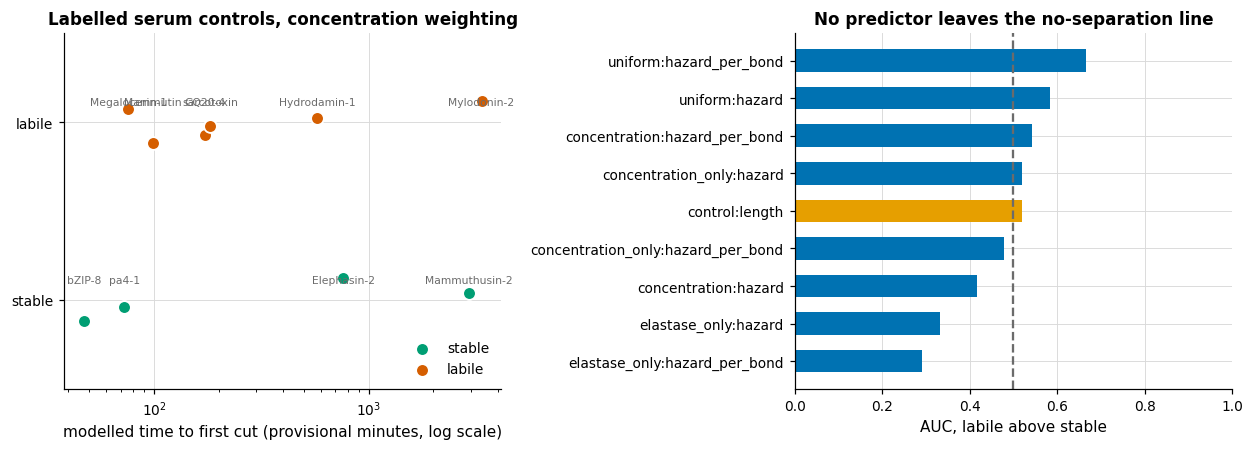

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

## Modelled time by label, one weighting
ax = axes[0]
shown = discrimination[discrimination["weighting"] == "concentration"]
for offset, (fate, colour) in enumerate(
    zip(("stable", "labile"), (common.CATEGORICAL_COLORS[2], common.CATEGORICAL_COLORS[1]))
):
    group = shown[shown["serum_fate"] == fate]
    ax.scatter(
        group["mean_time_minutes"],
        np.full(len(group), offset) + np.linspace(-0.12, 0.12, len(group)),
        s=70,
        color=colour,
        edgecolor="white",
        linewidth=1.2,
        zorder=3,
        label=fate,
    )
    for _, row in group.iterrows():
        ax.annotate(
            row["short"],
            (row["mean_time_minutes"], offset),
            textcoords="offset points",
            xytext=(0, 11),
            ha="center",
            fontsize=7,
            color=common.NEUTRAL,
        )
ax.set_xscale("log")
ax.set_yticks([0, 1])
ax.set_yticklabels(["stable", "labile"])
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("modelled time to first cut (provisional minutes, log scale)")
ax.set_title("Labelled serum controls, concentration weighting")
ax.legend(frameon=False, loc="lower right")

## AUC of every predictor
ax = axes[1]
colours = [
    common.CATEGORICAL_COLORS[3] if name.startswith("control") else common.CATEGORICAL_COLORS[0]
    for name in summary_frame["predictor"]
]
ax.barh(summary_frame["predictor"], summary_frame["auc"], color=colours, height=0.6)
ax.axvline(0.5, color=common.NEUTRAL, linewidth=1.5, linestyle="--")
ax.set_xlim(0, 1)
ax.set_xlabel("AUC, labile above stable")
ax.set_title("No predictor leaves the no-separation line")
ax.invert_yaxis()

fig.tight_layout()
plt.show()

## The labelled controls under every weighting

The strip plot above shows one weighting. That is not enough to answer whether the
model can separate these peptides at all: a strategy that fails may simply be the
wrong strategy, and the only way to tell is to put every strategy on the same axes.

Below, each weighting gets its own panel and each metric its own row. A strategy
that works would show the two label groups occupying different parts of its axis.

### What the labels rest on, exactly

The `serum_fate` column is not a measurement in this repository; it is an
annotation carried with the peptides, and its provenance decides how much weight a
separation could bear:

* the peptides come from **two unrelated sources**, five from a set of designed
  antimicrobials and five from a palaeogenomics supplement, so the assay behind
  `stable` is not necessarily the assay behind `labile`;
* **three of the ten are recorded as inactive**, and an inactive peptide's serum
  fate may never have been measured the way an active one's was;
* the annotation is **binary**, with no half-life, no matrix stated and no
  incubation time, so a peptide called `labile` in one source and one called
  `labile` in the other need not have degraded at comparable rates.

This is the weakest evidence in the whole analysis, and it is used only to ask
whether a large effect exists. The panels below are read as "does any strategy
separate these ten peptides", not as a measurement of how well.

what the labels rest on:
          source serum_fate  peptides  active  median_length
         OmegAMP     labile         3       3           20.0
         OmegAMP     stable         2       2           31.5
Paleogenomics SI     labile         3       2           15.0
Paleogenomics SI     stable         2       0           13.5

peptides recorded inactive: 3 of 10


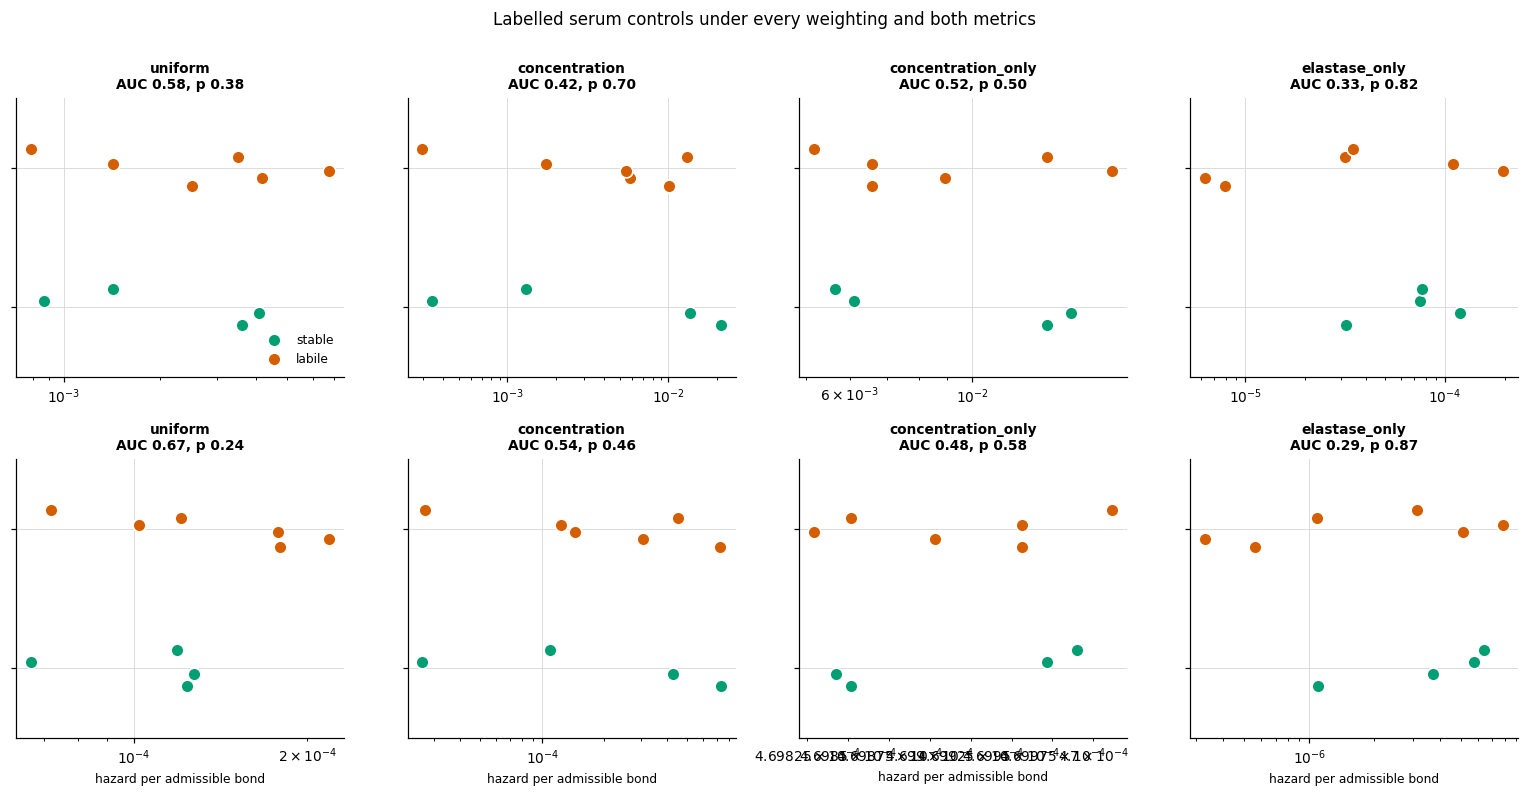


         weighting          metric   auc  p_value
           uniform          hazard 0.583    0.381
           uniform hazard_per_bond 0.667    0.238
     concentration          hazard 0.417    0.695
     concentration hazard_per_bond 0.542    0.457
concentration_only          hazard 0.521    0.500
concentration_only hazard_per_bond 0.479    0.585
     elastase_only          hazard 0.333    0.824
     elastase_only hazard_per_bond 0.292    0.871

best strategy: uniform on hazard_per_bond, AUC 0.667, p 0.238
chance is 0.5; the smallest attainable p at four against six is 0.0048


PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/3_03_label_provenance.csv')

In [8]:
provenance = controls.groupby(["source", "serum_fate"]).agg(
    peptides=("sequence", "size"),
    active=("active", "sum"),
    median_length=("sequence", lambda values: float(np.median([len(v) for v in values]))),
).reset_index()
print("what the labels rest on:")
print(provenance.to_string(index=False))
print()
print(f"peptides recorded inactive: {int((~controls['active']).sum())} of {len(controls)}")

METRICS = {"hazard": "hazard (events per provisional minute)",
           "hazard_per_bond": "hazard per admissible bond"}
weightings = list(variants)

fig, axes = plt.subplots(len(METRICS), len(weightings), figsize=(14.0, 7.2), sharey=True)
for row, (metric, metric_label) in enumerate(METRICS.items()):
    for column, weighting in enumerate(weightings):
        ax = axes[row, column]
        subset = discrimination[discrimination["weighting"] == weighting]
        for offset, (fate, colour) in enumerate(
            zip(("stable", "labile"), (common.CATEGORICAL_COLORS[2], common.CATEGORICAL_COLORS[1]))
        ):
            group = subset[subset["serum_fate"] == fate]
            ax.scatter(
                group[metric],
                np.full(len(group), offset) + np.linspace(-0.13, 0.13, len(group)),
                s=70, color=colour, edgecolor="white", linewidth=1.1, zorder=3,
                label=fate if (row == 0 and column == 0) else None,
            )
        ## The AUC of this exact panel, so the picture and the number agree
        labile_values = subset.loc[subset["serum_fate"] == "labile", metric].to_numpy()
        stable_values = subset.loc[subset["serum_fate"] == "stable", metric].to_numpy()
        auc, p_value = separation(labile_values, stable_values)
        ax.set_xscale("log")
        ax.set_ylim(-0.5, 1.5)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["stable", "labile"] if column == 0 else ["", ""])
        ax.set_title(f"{weighting}\nAUC {auc:.2f}, p {p_value:.2f}", fontsize=9)
        if row == len(METRICS) - 1:
            ax.set_xlabel(metric_label, fontsize=8)
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Labelled serum controls under every weighting and both metrics", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

## The same thing as numbers, so no panel has to be eyeballed
grid = []
for weighting in weightings:
    subset = discrimination[discrimination["weighting"] == weighting]
    for metric in METRICS:
        auc, p_value = separation(
            subset.loc[subset["serum_fate"] == "labile", metric].to_numpy(),
            subset.loc[subset["serum_fate"] == "stable", metric].to_numpy(),
        )
        grid.append({"weighting": weighting, "metric": metric, "auc": auc, "p_value": p_value})
grid_frame = pd.DataFrame(grid)
best = grid_frame.loc[grid_frame["auc"].idxmax()]
print()
print(grid_frame.round(3).to_string(index=False))
print(f"\nbest strategy: {best['weighting']} on {best['metric']}, AUC {best['auc']:.3f}, p {best['p_value']:.3f}")
print(f"chance is 0.5; the smallest attainable p at four against six is {1 / 210:.4f}")

common.save_result(grid_frame, "3_03_strategy_grid.csv")
common.save_result(provenance, "3_03_label_provenance.csv")

### What the provenance table shows, and why it matters more than the panels

| source | fate | peptides | active | median length |
| --- | --- | --- | --- | --- |
| OmegAMP | labile | 3 | 3 | 20.0 |
| OmegAMP | stable | 2 | 2 | **31.5** |
| Paleogenomics SI | labile | 3 | 2 | 15.0 |
| Paleogenomics SI | stable | 2 | **0** | 13.5 |

Two things are visible that no panel above can show.

**Both peptides the palaeogenomics source calls `stable` are recorded as
inactive.** For an inactive peptide, "stable in serum" need not be a proteolytic
statement at all — there may have been no activity to lose and no degradation assay
to run. Half the `stable` class is therefore a label of uncertain kind.

**The label is confounded with length, in opposite directions between the two
sources.** In OmegAMP the stable peptides are much longer than the labile ones
(31.5 against 20 residues); in the palaeogenomics set they are slightly shorter
(13.5 against 15). A predictor with any length dependence is pulled one way by the
first source and the other way by the second, which is enough on its own to cancel a
real effect across the pooled ten.

**Consequence.** The grid of strategies answers the question it was asked — no
weighting and no metric separates these peptides, the best reaching AUC 0.67 at
$p = 0.24$ — but a negative result on this label set is weaker than it looks. It
does not establish that the model cannot discriminate serum stability; it
establishes that this annotation cannot test whether it can. The matched pairs of
the next section are the stronger evidence, because there the two members of a pair
come from one publication, one assay and one scaffold.

## Test 2: matched pairs from the biologist's control table

The unpaired test confounds every property of the scaffold with the label. The
control table holds pairs that do not: a parent and a variant of it whose serum
or protease fate the literature reports as different.

| Pair | Modification | Published result | Length matched |
| --- | --- | --- | --- |
| EFK17 → EFK17-W | four Trp at the P1′ positions | stabilised against HNE, aureolysin and V8, **not** against LasB | yes, 17 and 17 |
| CAM → CAM-W | four Trp substitutions | improved stability against a panel including HNE | yes, 26 and 26 |
| bCAT → bCTL | C-terminal truncation | not degraded by any of four *S. aureus* strains | no, 21 and 15 |
| LL-37 → LL-17-37 | V8 product | refractory to further V8 cleavage | no, 37 and 21 |

Only the first two are clean tests of the human serum model. The third is
recorded in the table as a **counterexample**: `bCTL` keeps both of the parent's
cleaved bonds with identical P4–P4′ windows, so a window-only model has no
mechanism for its resistance and must not be credited for getting it right. The
fourth is protease-conditional on a bacterial enzyme absent from the human panel.
All four are computed so that the failure modes stay visible.

In [9]:
PAIRS = (
    ("EFK17", "EFKRIVQRIKDFLRNLV", "EFK17-W", "EWKRWVQRWKDWLRNLV", "length_matched"),
    ("CAM", "KWKLFKKIEKVGQGIGAVLKVLTTGL", "CAM-W", "KWKLWKKIEKWGQGIGAVLKWLTTWL", "length_matched"),
    ("bCAT", "RSMRLSFRARGYGFRGPGLQL", "bCTL", "RSMRLSFRARGYGFR", "counterexample"),
    ("LL-37", "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES", "LL-17-37", "FKRIVQRIKDFLRNLVPRTES", "not_human_panel"),
)

pair_records = []
for labile_name, labile_sequence, stable_name, stable_sequence, status in PAIRS:
    for name, kinetics in variants.items():
        _, _, time_labile = first_cut_distribution(labile_sequence, kinetics, human_background)
        _, _, time_stable = first_cut_distribution(stable_sequence, kinetics, human_background)
        bonds_labile = max(len(labile_sequence) - 1, 1)
        bonds_stable = max(len(stable_sequence) - 1, 1)
        pair_records.append(
            {
                "pair": f"{labile_name} to {stable_name}",
                "status": status,
                "weighting": name,
                "time_labile": time_labile,
                "time_stable": time_stable,
                "fold_change": time_stable / time_labile,
                "fold_change_per_bond": (time_stable * bonds_stable) / (time_labile * bonds_labile),
                "direction_correct": bool(time_stable > time_labile),
            }
        )

pairs_frame = pd.DataFrame(pair_records)
print(
    pairs_frame.pivot_table(index=["pair", "status"], columns="weighting", values="fold_change")
    .round(2)
    .to_string()
)
clean = pairs_frame[pairs_frame["status"] == "length_matched"]
print("\nlength-matched pairs, direction correct:")
print(clean.groupby("weighting")["direction_correct"].mean().to_string())

weighting                          concentration  concentration_only  elastase_only  uniform
pair              status                                                                    
CAM to CAM-W      length_matched            1.09                1.00           1.26     0.85
EFK17 to EFK17-W  length_matched            1.11                1.00           4.56     0.58
LL-37 to LL-17-37 not_human_panel           0.74                1.80           1.63     1.18
bCAT to bCTL      counterexample            1.60                1.43           1.82     1.49

length-matched pairs, direction correct:
weighting
concentration         1.0
concentration_only    0.0
elastase_only         1.0
uniform               0.0


### Reading the figure

Each bar is the fold change in modelled time from parent to variant. A bar to
the right of $1$ is a prediction that the variant survives longer, which is what
the literature reports for all four pairs. Bars are grouped by the kinetics used;
`elastase_only` is the enzyme in which the EFK17-W and CAM-W results were
actually measured, the other three are whole-panel serum models.

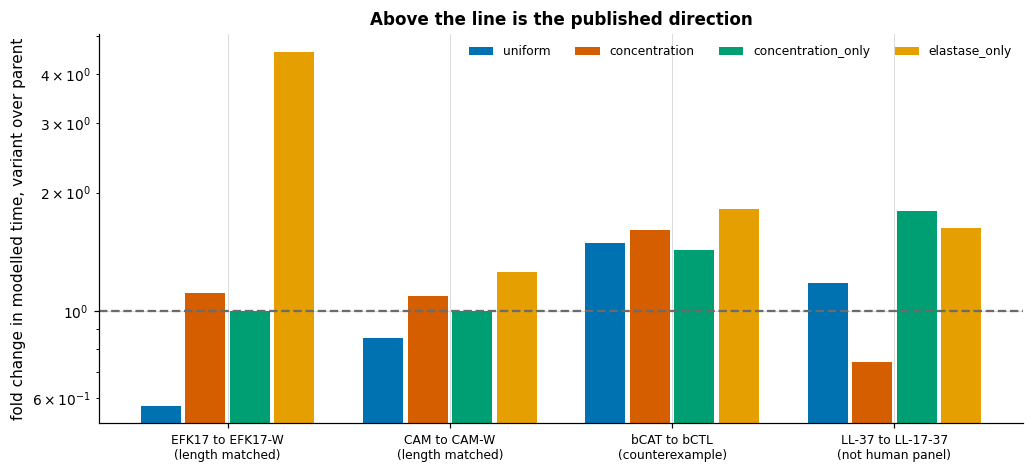

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
order = [name for name in variants]
width = 0.2
for position, name in enumerate(order):
    subset = pairs_frame[pairs_frame["weighting"] == name].set_index("pair")
    labels = [record[0] + " to " + record[2] for record in PAIRS]
    values = subset.loc[labels, "fold_change"].to_numpy()
    ax.bar(
        np.arange(len(labels)) + (position - 1.5) * width,
        values,
        width=width * 0.9,
        color=common.CATEGORICAL_COLORS[position],
        label=name,
    )
ax.axhline(1.0, color=common.NEUTRAL, linewidth=1.5, linestyle="--")
ax.set_yscale("log")
ax.set_xticks(np.arange(len(PAIRS)))
ax.set_xticklabels(
    [f"{record[0]} to {record[2]}\n({record[4].replace('_', ' ')})" for record in PAIRS], fontsize=8
)
ax.set_ylabel("fold change in modelled time, variant over parent")
ax.set_title("Above the line is the published direction")
ax.legend(frameon=False, ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

In [11]:
common.save_result(discrimination, "3_03_control_discrimination.csv")
common.save_result(pairs_frame, "3_03_matched_pairs.csv")
common.save_result(summary_frame, "3_03_separation_summary.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/3_03_separation_summary.csv')

## What this establishes

**The panel hazard does not classify the labelled serum controls.** No predictor
leaves the neighbourhood of AUC $0.5$, in either direction, under any weighting,
and the length control does not separate them either. The sample is small enough
that a moderate effect could hide in it, but the observed effect is not moderate:
it is absent. Two peptides carry the point. `Mylodonin-2` is the most stable
peptide the model produces and is labelled labile; `bZIP-8` and `pa4-1` are
labelled stable and receive two of the three shortest times.

**The matched pairs behave differently, and the reason is instructive.** The two
length-matched Trp-substitution pairs move in the published direction under the
concentration weighting and under elastase alone, and against it under the
uniform weighting. The effect is an order of magnitude larger in the single
enzyme than in the panel: EFK17-W is predicted to survive $4.6\times$ longer
than EFK17 against HNE, but only $1.1\times$ longer against the whole panel.
That gap is the diagnostic. The substitution changes the P1′ preference of one
enzyme; forty-six other proteases continue to contribute hazard that the
substitution does not touch, and the panel sum dilutes a real effect into
nothing. With four pairs the sign test cannot reach $p < 0.05$ even when every
pair agrees, so this is a direction with a magnitude, not a significant result.

**The internal control settles where that magnitude comes from.** Under
`concentration_only` the slope $\beta$ is zero, so the score is switched off and
the hazard depends only on the number of admissible bonds. Both Trp pairs are
length-matched, so that variant is obliged to return a fold change of exactly
$1.00$, and it does. Every departure from $1.00$ under the other variants is
therefore contributed by the specificity matrices and by nothing else. The
$4.56\times$ against HNE is a matrix result, not a length artefact.

**Consequences.**

1. The model should not be used as a stability classifier on unrelated
   scaffolds. Nothing here supports that use.
2. Where a single responsible protease is known, the matrix does carry the
   published specificity, and predictions conditioned on that enzyme are the ones
   worth making. This agrees with `4_01`, where thrombin alone dominated the
   hazard of 229 of 300 peptides, and with `2_04`, where only a handful of
   enzymes survived held-out validation.
3. The dilution is a property of the summation, not of the data. A panel model
   weighted only by abundance cannot express that one enzyme's preference has
   changed; an informative panel needs per-enzyme rate constants, which is what
   validation B failed to supply.

**What would settle it.** The labelled set needs to be an order of magnitude
larger, and the labels need to come from one assay: the present ten mix two
sources, and three of the peptides are recorded as inactive, so their `serum_fate`
is not necessarily measured the same way as the rest. Failing that, more
length-matched engineered pairs with a named protease would extend test 2, which
is the only test here with any resolving power.